In [13]:
pip install cvxpy ecos

Note: you may need to restart the kernel to use updated packages.


In [18]:
pip install ecos scs clarabel osqp

Note: you may need to restart the kernel to use updated packages.


In [16]:
import ecos

In [58]:
import numpy as np
import pandas as pd
import yfinance as yf
from pypfopt import risk_models, expected_returns
from pypfopt.hierarchical_portfolio import HRPOpt
import matplotlib.pyplot as plt
import datetime as dt
import statsmodels.api as sm

In [5]:
df = pd.read_csv("data/scores_for_top.csv")
df_f = df[df.ds >= "2023-01-01"]
df_f["ds"] = pd.to_datetime(df['ds'])
df_f

C:\Users\user\AppData\Local\Temp\ipykernel_13584\1269492789.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_f["ds"] = pd.to_datetime(df['ds'])


,symbol,ds,prediction,y
91,AMT,2023-01-01,-0.006343,-0.113613
92,AMT,2023-02-01,-0.002760,0.031968
93,AMT,2023-03-01,-0.005736,0.000245
94,AMT,2023-04-01,-0.004182,-0.090894
95,AMT,2023-05-01,-0.001853,0.051507
...,...,...,...,...
7492,XEL,2024-12-01,0.001963,-0.004739
7493,XEL,2025-01-01,-0.006069,0.081806
7494,XEL,2025-02-01,-0.020242,-0.018169
7495,XEL,2025-03-01,-0.010216,0.007088


In [57]:
df_pivot = df_f.pivot(index='ds', columns='symbol', values='prediction')

# При желании можно преобразовать индекс в datetime
df_pivot.index = pd.to_datetime(df_pivot.index)
df_pivot.head()

symbol,AMT,AOS,APTV,BBWI,BEN,BIIB,CAT,CCI,CHRW,CL,...,SBUX,SNPS,T,UHS,UPS,VMC,WDC,WEC,WHR,XEL
ds,,,,,,,,,,,,,,,,,,,,,
2023-01-01,-0.006343,-0.015478,0.027506,0.005662,-0.029963,-0.024615,0.016673,0.011333,-0.017680,0.017622,...,0.046512,0.059515,0.006476,-0.039751,0.015549,-0.001727,0.138016,-0.000258,-0.012740,0.006938
2023-02-01,-0.002760,-0.009675,0.014353,-0.021633,-0.047983,0.020147,0.009470,0.023543,-0.025850,0.012206,...,0.024120,0.061494,0.005085,-0.002815,0.017896,0.002230,0.183582,0.011250,-0.017293,0.001235
2023-03-01,-0.005736,-0.011868,0.024953,-0.033418,-0.002435,0.013275,0.009637,0.015327,-0.008152,0.008508,...,0.031890,0.030728,-0.004756,-0.007804,0.020782,-0.009306,0.183969,-0.000868,-0.012685,0.001260
2023-04-01,-0.004182,-0.011433,0.024624,-0.036342,0.001216,-0.040852,0.011243,0.014318,-0.026095,0.001603,...,0.045235,0.025829,-0.002114,-0.029348,0.001217,-0.008703,0.183125,-0.006215,-0.000223,-0.000996
2023-05-01,-0.001853,-0.012650,0.104167,-0.039376,0.024398,0.028841,0.019516,0.013262,0.000962,0.010114,...,0.029869,0.033422,0.040352,-0.019178,0.000735,-0.002748,0.153350,0.015720,-0.008428,0.000654


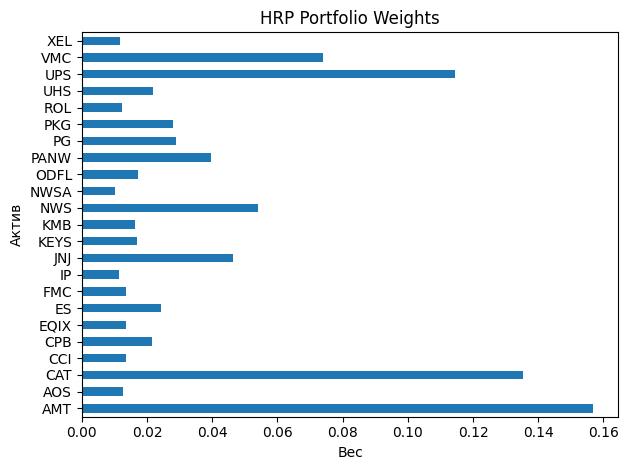

In [7]:
# Создаем объект HRP
hrp = HRPOpt(df_pivot)

# Кластеризация + вычисление весов
weights = hrp.optimize()

# Преобразуем в DataFrame
weights_df = pd.DataFrame.from_dict(weights, orient='index', columns=['Weight'])

# Фильтруем только те актива с ненулевым весом
weights_df = weights_df[weights_df['Weight'] > 0.01]

# Построим график
weights_df.plot(kind='barh', title='HRP Portfolio Weights', legend=False)
plt.xlabel('Вес')
plt.ylabel('Актив')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

def calc_portfolio_profit(df, weights, window=12):
    """
    Улучшенная функция, которая:
    1. Автоматически определяет целевую дату (min_date + window месяцев)
    2. Считает скользящую доходность для каждого символа
    3. Вычисляет прибыль портфеля с учётом весов (лонги/шорты)
    
    Параметры:
    - df: DataFrame с колонками ['symbol', 'ds', 'y'] (символ, дата, доходность)
    - weights: Series с весами (индекс = символы)
    - window: размер окна для расчёта скользящей доходности (в месяцах)
    
    Возвращает:
    - DataFrame с доходностями и прибылью на целевую дату
    """
    
    # 1. Фильтруем только нужные символы
    symbols = weights.index.tolist()
    df_filtered = df[df['symbol'].isin(symbols)].copy()
    
    # 2. Рассчитываем целевую дату (min_date + window месяцев)
    min_date = df_filtered['ds'].min()
    target_date = min_date + pd.DateOffset(months=window)
    
    # 3. Функция для расчёта скользящей доходности
    def rolling_return(group):
        group[f'y_{window}m'] = (
            (group['y'] + 1)
            .rolling(window=window)
            .apply(np.prod, raw=True) - 1
        )
        return group
    
    # 4. Применяем rolling_return к каждому символу
    df_with_returns = df_filtered.groupby('symbol', group_keys=False).apply(rolling_return)
    
    # 5. Фильтруем данные на целевую дату
    df_profit = (
        df_with_returns[df_with_returns['ds'] == target_date]
        [[f'y_{window}m', 'symbol']]
        .set_index('symbol')
    )
    
    # 6. Добавляем прибыль с учётом весов (лонги/шорты)
    display(df_profit)
    df_profit['profit'] = df_profit[f'y_{window}m'] * weights['Weight']
    
    
    return df_profit


In [15]:
calc_portfolio_profit(df_f, weights_df, window=18)[["profit"]].sum()

,y_18m
symbol,
AMT,0.190444
AOS,0.307663
CAT,0.528492
CCI,-0.066783
CPB,-0.005878
EQIX,0.249140
ES,-0.045148
FMC,-0.475411
IP,0.438985


profit    0.2469
dtype: float64

In [ ]:
# Расчет финансовых метрик потрфеля

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm

market_ticker = '^GSPC'            # рыночный индекс (S&P 500)
risk_free_rate = 0.02              # безрисковая ставка (годовая)
start_date = '2023-01-01'
end_date = '2025-04-01'

# Загрузка данных
data = yf.download([market_ticker], start=start_date, end=end_date, interval="1mo")["Close"]

# Рассчитываем доходности
returns = data.pct_change().dropna()

# Доходность портфеля как взвешенная сумма

portfolio_returns = (df_pivot[weights_df.index]  * weights_df["Weight"]).sum(axis=1)

# Объединяем доходности портфеля и рынка
combined_returns = pd.DataFrame({
    'portfolio': portfolio_returns,
    'market': returns[market_ticker]
}).dropna()

# Sharpe Ratio
def calculate_sharpe_ratio(portfolio_returns, risk_free_rate=0.02):
    # Месячная безрисковая ставка
    monthly_rf = risk_free_rate / 12
    
    # Избыточная доходность (месячная)
    excess_return_monthly = portfolio_returns - monthly_rf
    
    # Годовая избыточная доходность
    annualized_excess_return = excess_return_monthly.mean() * 12
    
    # Годовая волатильность (std месячных доходностей, умноженная на sqrt(12))
    annualized_volatility = excess_return_monthly.std() * np.sqrt(12)
    
    # Sharpe Ratio
    sharpe_ratio = annualized_excess_return / annualized_volatility
    
    return sharpe_ratio

sharpe_ratio = calculate_sharpe_ratio(combined_returns['portfolio'], risk_free_rate)
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

# Beta и Alpha через регрессию
X = sm.add_constant(combined_returns['market'])  # добавляем константу
y = combined_returns['portfolio']

model = sm.OLS(y, X).fit()
beta = model.params['market']
alpha = model.params['const'] * 12  # годовой alpha

print(f"Beta: {beta:.2f}")
print(f"Alpha: {alpha:.4f} или {alpha*100:.2f}%")

[*********************100%***********************]  1 of 1 completed

Sharpe Ratio: 6.54
Beta: -0.01
Alpha: 0.0612 или 6.12%


1. Sharpe Ratio = 6.54
🔍 Что это?
Sharpe Ratio показывает, насколько хорошо доходность портфеля компенсирует его риск (волатильность). Формула:

Sharpe= 
Годовая волатильность
Избыточная доходность (годовая)
​
 
🧮 Интерпретация:
Обычно считается:
1 — хороший 
2 — очень хороший 
3 — отличный 
У тебя значение 6.54 — это очень высокое , и означает, что портфель приносит огромную доходность относительно риска .
❗ Важно:
Такое значение может быть связано с:

Коротким периодом анализа (например, всего несколько месяцев роста),
Низкой волатильностью,
Аномальным ростом портфеля.
📌 Вывод : Если всё посчитано верно — твой портфель работает чрезвычайно эффективно по соотношению риск/доходность.

📊 2. Beta = -0.01
🔍 Что это?
Beta показывает, как движется твой портфель относительно рынка (S&P 500). Формула:

β= 
Var(R 
m
​
 )
Cov(R 
p
​
 ,R 
m
​
 )
​
 
🧮 Интерпретация:
Beta ≈ 0 → портфель почти не зависит от рынка
Beta < 0 → портфель движется в противоположную сторону от рынка
У тебя Beta = -0.01 → почти ноль, но слегка негативная корреляция с рынком
Пример:

Если S&P 500 упадёт на 1%, то твой портфель, в среднем, вырастет на 0.01% 

📌 Вывод : Портфель практически не реагирует на рынок , возможно содержит:

защитные активы,
альтернативные инвестиции,
инструменты с хеджированием.
📊 3. Alpha = 6.12%
🔍 Что это?
Alpha — это избыточная доходность портфеля относительно того, что предсказывает модель CAPM, с учётом его Beta.

Формула модели CAPM:

R 
p
​
 =α+β⋅R 
m
​
 +ε
🧮 Интерпретация:
Alpha = 6.12% годовых → твой портфель зарабатывает на 6.12% больше , чем ожидалось, исходя из его риска (Beta)
Это говорит о хорошем менеджменте или сильной переоценке активов
📌 Вывод : Твой портфель генерирует положительную избыточную доходность , даже несмотря на почти нулевую корреляцию с рынком.

✅ ИТОГО: твой портфель выглядит так:
Sharpe Ratio
6.54
Очень высокий — эффективность портфеля
Beta
-0.01
Почти независим от рынка
Alpha
6.12%
Положительный "альфа" — добавленная стоимость

🎯 Рекомендации:
Проверь временной период : если анализ по нескольким месяцам — результаты могут быть случайными.
Добавь график кумулятивных доходностей — сравни портфель с рынком.
Проверь состав портфеля — возможно, он содержит сильно растущие или маловолатильные бумаги.
Устойчивость Alpha : проверь, держится ли alpha в разных рыночных условиях.
Если хочешь, я могу помочь тебе:

Построить график кумулятивного роста портфеля vs рынка
Проверить данные на выбросы
Сделать rolling window аналитику для Alpha и Beta
Хочешь?